In [1]:
from IPython.display import display, HTML 
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:15pt;}
div.output {font-size:15pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:15pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

In [14]:
import numpy as np
import pandas as pd
from tensorflow.keras.datasets import mnist # mnist 데이터 셋
from tensorflow.keras.utils import to_categorical # 원핫인코딩
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout
from matplotlib import pyplot as plt # 학습과정 loss와 acc 시각화
from sklearn.metrics import confusion_matrix # 혼동 행렬
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split # 데이터 분리
# quiz에서는 scale조정, train_test_split 등을 추가

- Red Wine 등급 예측
1. 데이타 셋 확보 및 전처리
    csv -> 결측치 처리 -> 독립변수와 타겟변수 분리 -> 독립변수 스케일 조정,
        -> 타겟변수의 원핫인코딩 -> 훈련셋과 테스트셋분리(train_tes_split이용 층화 추출)
2. 모델 구성(입력 11, 출력6-pd.getdummies. 출력9-to_categorical)
3. 모델 학습 과정 설정
4. 모델 학습(callback이용)
5. 모델 평가(그래프, 평가, 교차표)
6. 모델 저장 & 사용

# 1. 데이터 확보 & 전처리

In [42]:
# 데이터 읽어오기
# fixed acidity : 고정 산도
# volatile acidity : 휘발성 산도
# citric acid : 시트르산
# residual sugar : 잔류 당분
# chlorides : 염화물
# free sulfur dioxide : 자유 이산화황
# total sulfur dioxide : 총 이산화황
# density : 밀도
# pH
# sulphates : 황산염
# alcohol
# quality : 0 ~ 10(높을 수록 좋은 품질)
redwine = pd.read_csv('data/winequality-red.csv', sep=';')
redwine['quality'].value_counts() # 품질 등급이 3~8까지 6개 등급
redwine.info() # 결측 無 11 + 1, 1599 개 데이터

# X, y 분리
X = redwine.iloc[:,:-1].values
y = redwine.iloc[:,-1].values

# X 스케일링 by MinMaxScaler
scaler_x = MinMaxScaler()
scaled_X = scaler_x.fit_transform(X)

# scaled_X, y를 학습셋, 테스트셋 8:2로 분리
X_train, X_test, y_train, y_test = train_test_split(scaled_X,
                                                   y,
                                                   test_size=0.20, # 테스트 셋 비율
                                                   random_state=7,
                                                   stratify=y) # 층화 추출
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

# 등급별 비율 확인 => OK
print(pd.DataFrame(y).value_counts(normalize=True)) # 전체 데이터
print(pd.DataFrame(y_train).value_counts(normalize=True)) # y_train 데이터
print(pd.DataFrame(y_test).value_counts(normalize=True)) # y_test 데이터

# y 원핫인코딩 => # 6개 실적 데이터지만 9등급으로 분류
Y_train = to_categorical(y_train)
Y_test = to_categorical(y_test)
Y_train = Y_train[:,3:9] # get.dummies 의미
Y_test = Y_test[:,3:9]
Y_train[:5]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB
(1279, 11) (320, 11) (1279,) (320,)
5    0.425891
6    0.398999
7    0.124453
4    0.033146
8    0.011257
3    0.006254
dtype:

array([[0., 0., 1., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 1., 0., 0.]], dtype=float32)

In [46]:
%%time
# 모델 구성
# 매번 로그 출력하면 지저분해 질 수 있으니, 특정 에포크마다 로그 출력하도록 제한
from tensorflow.keras.callbacks import Callback, EarlyStopping, ModelCheckpoint

class CustomHistory(Callback):
    def __init__(self): # 생성자함수
        self.epoch = 0
    def on_epoch_end(self, batch, logs={}): # 1epoch마다 자동 실행되는 함수
        self.epoch +1  # epoch맏 self.epoch값을 1씩 증가
        if self.epoch%10 == 0:
            print('epoch:{}, loss:{}, acc:{}, val_loss:{}, val_acc:{},'.\
                  format(self.epoch, 
                        logs.get('loss'),
                        logs.get('accuracy', '-'),
                        logs.get('val_loss', '-'),
                        logs.get('val_accuracy', '-')
                        )
                 )
            
# 2. 모델 생성(입력11, 출력6) & 학습과정 설정 & 학습 = > 135백여개 파라미터
model = Sequential()
model.add(Input(shape=(11,)))
model.add(Dense(units=44, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(units=132, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(units=396, activation='relu'))
model.add(Dropout(0.2))
from tensorflow.keras.layers import LeakyReLU
model.add(LeakyReLU(alpha=0.01)) 
model.add(Dropout(0.3))
model.add(Dense(units=198, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(units=99, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(units=6, activation='sigmoid'))
model.summary()

# 3. 모델 평가(그래프, 평가, 교차표)
from tensorflow.keras import metrics
from tensorflow.keras.optimizers import Adam
model.compile(loss='binary_crossentropy',
             optimizer=Adam(learning_rate=0.01),
             metrics=['accuracy', # 정확도
                      metrics.Recall(), # 재현율(실제값 중심)
                      metrics.Precision()]) # 정밀도(예측값 중심)

customHistory = CustomHistory()
# monitor기준으로 patience번 이상 안 좋은 데이터가 나오면 조기 종료
earlystopping = EarlyStopping(monitor='val_accuracy', patience=20)

# 모델 자동 저장 콜백
import os
model_save_folder = './modelwine/'
if not os.path.exists(model_save_folder): # 폴더가 없으면 폴던 생성
    os.mkdir(model_save_folder)
file = model_save_folder + 'mnist-{epoch:03d}-val{val_accuracy:.4f}.h5'
checkpoint = ModelCheckpoint(filepath=file,
                        monitor='val_accuracy', # 모니터할 지표
                        save_best_only=True, # 모니터링 지표가 개선된 경우만 저장
                        mode='max', # 값이 클수록 저장
                        verbose=1 # 저장시 로그 출력
                      )

# 4. 모델 사용(저장, 예측)

hist = model.fit(X_train, Y_train,
                epochs=500,
                batch_size=400,
                validation_split=0.2, # 검증데이터를 훈련데이터의 20%로 사용
                verbose=1,
                callbacks=[customHistory, earlystopping, checkpoint]) # 콜백함수

Model: "sequential_10"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_52 (Dense)            (None, 44)                528       
                                                                 
 dropout_49 (Dropout)        (None, 44)                0         
                                                                 
 dense_53 (Dense)            (None, 132)               5940      
                                                                 
 dropout_50 (Dropout)        (None, 132)               0         
                                                                 
 dense_54 (Dense)            (None, 396)               52668     
                                                                 
 dropout_51 (Dropout)        (None, 396)               0         
                                                                 
 leaky_re_lu_7 (LeakyReLU)   (None, 396)             

1/3 [=========>....................] - ETA: 0s - loss: 0.3046 - accuracy: 0.5475 - recall_9: 0.2300 - precision_9: 0.6216epoch:0, loss:0.3086231052875519, acc:0.5513196587562561, val_loss:0.28998398780822754, val_acc:0.58203125,

Epoch 12: val_accuracy improved from 0.56250 to 0.58203, saving model to ./modelwine\mnist-012-val0.5820.h5
3/3 [==============================] - 0s 45ms/step - loss: 0.3086 - accuracy: 0.5513 - recall_9: 0.2776 - precision_9: 0.6030 - val_loss: 0.2900 - val_accuracy: 0.5820 - val_recall_9: 0.4453 - val_precision_9: 0.6000
Epoch 13/500
1/3 [=========>....................] - ETA: 0s - loss: 0.2953 - accuracy: 0.5725 - recall_9: 0.3850 - precision_9: 0.6498epoch:0, loss:0.3012768626213074, acc:0.5601173043251038, val_loss:0.28966209292411804, val_acc:0.60546875,

Epoch 13: val_accuracy improved from 0.58203 to 0.60547, saving model to ./modelwine\mnist-013-val0.6055.h5
3/3 [==============================] - 0s 48ms/step - loss: 0.3013 - accuracy: 0.5601 - recal

Epoch 28/500
1/3 [=========>....................] - ETA: 0s - loss: 0.2816 - accuracy: 0.5825 - recall_9: 0.4850 - precision_9: 0.6044epoch:0, loss:0.284535676240921, acc:0.5855327248573303, val_loss:0.2772929072380066, val_acc:0.61328125,

Epoch 28: val_accuracy did not improve from 0.62500
3/3 [==============================] - 0s 31ms/step - loss: 0.2845 - accuracy: 0.5855 - recall_9: 0.4956 - precision_9: 0.6094 - val_loss: 0.2773 - val_accuracy: 0.6133 - val_recall_9: 0.5000 - val_precision_9: 0.6632
Epoch 29/500
1/3 [=========>....................] - ETA: 0s - loss: 0.2857 - accuracy: 0.6000 - recall_9: 0.5125 - precision_9: 0.6743epoch:0, loss:0.28182995319366455, acc:0.5953079462051392, val_loss:0.2692732810974121, val_acc:0.59375,

Epoch 29: val_accuracy did not improve from 0.62500
3/3 [==============================] - 0s 28ms/step - loss: 0.2818 - accuracy: 0.5953 - recall_9: 0.4927 - precision_9: 0.6372 - val_loss: 0.2693 - val_accuracy: 0.5938 - val_recall_9: 0.5195 - val

Epoch 44/500
1/3 [=========>....................] - ETA: 0s - loss: 0.2718 - accuracy: 0.6000 - recall_9: 0.5375 - precision_9: 0.6456epoch:0, loss:0.27215737104415894, acc:0.6217008829116821, val_loss:0.26685091853141785, val_acc:0.6171875,

Epoch 44: val_accuracy did not improve from 0.63281
3/3 [==============================] - 0s 27ms/step - loss: 0.2722 - accuracy: 0.6217 - recall_9: 0.5288 - precision_9: 0.6464 - val_loss: 0.2669 - val_accuracy: 0.6172 - val_recall_9: 0.5391 - val_precision_9: 0.6419
Epoch 45/500
1/3 [=========>....................] - ETA: 0s - loss: 0.2661 - accuracy: 0.6250 - recall_9: 0.5450 - precision_9: 0.6527epoch:0, loss:0.26655328273773193, acc:0.6177908182144165, val_loss:0.2702982425689697, val_acc:0.61328125,

Epoch 45: val_accuracy did not improve from 0.63281
3/3 [==============================] - 0s 28ms/step - loss: 0.2666 - accuracy: 0.6178 - recall_9: 0.5406 - precision_9: 0.6475 - val_loss: 0.2703 - val_accuracy: 0.6133 - val_recall_9: 0.5430 

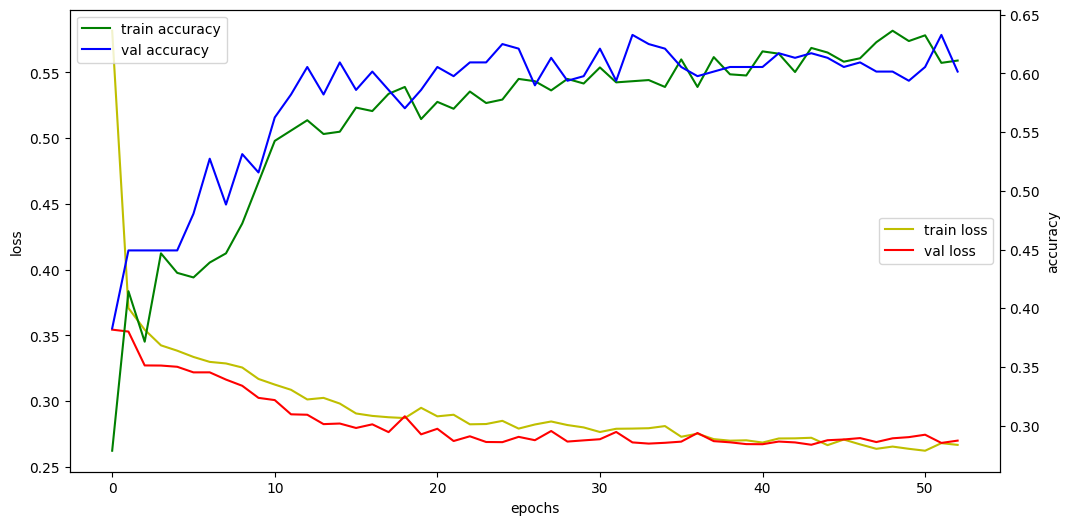

In [47]:
fig, loss_ax = plt.subplots(figsize=(12,6))
loss_ax.plot(hist.history['loss'], 'y', label='train loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val accuracy')
loss_ax.set_xlabel('epochs')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(loc='center right')
acc_ax.legend()
plt.show()

In [49]:
# 모델 평가하기
loss_and_mertics = model.evaluate(X_test, Y_test, batch_size=100, verbose=1)

# 교차표
y_hat = model.predict(X_test).argmax(axis=1)+3
print(y_hat)
pd.crosstab(y_test.reshape(-1), y_hat,
           rownames=['실제값'],
           colnames=['예측값'])

10/10 [==============================] - 0s 2ms/step
[5 5 5 5 6 5 6 5 5 5 5 7 6 6 6 6 5 6 7 7 6 6 5 6 6 6 5 5 6 6 7 5 5 5 5 5 6
 6 6 7 5 6 7 7 7 5 5 5 6 7 7 5 5 7 6 6 7 7 6 6 5 6 6 5 5 6 6 5 5 6 6 6 7 5
 5 5 5 5 7 5 6 5 6 6 6 7 5 7 6 6 6 5 7 6 7 6 5 6 7 6 5 6 6 7 6 6 7 5 6 5 6
 5 6 6 6 6 6 6 7 7 6 6 7 6 5 6 6 5 5 7 7 5 6 5 6 5 6 6 6 7 6 6 7 6 5 6 5 6
 6 5 6 5 6 5 6 6 7 7 5 5 5 5 5 5 6 6 6 7 6 5 6 6 5 5 5 6 5 7 6 5 6 6 5 6 6
 6 5 6 6 7 5 5 5 5 5 6 5 5 7 6 5 5 7 5 5 5 5 6 5 5 5 5 5 6 5 7 5 6 5 6 6 5
 6 5 6 6 6 6 6 5 5 5 5 6 7 5 5 5 7 5 5 5 6 6 5 5 5 5 6 7 6 6 6 5 7 6 6 6 6
 6 5 6 7 6 5 6 5 5 5 7 5 6 5 6 6 5 5 6 6 7 5 6 6 6 5 5 5 6 7 5 6 5 7 7 6 6
 6 6 7 5 5 5 5 7 6 5 5 5 5 5 7 5 6 5 5 5 6 6 6 6]


예측값,5,6,7
실제값,,,
3,2,0,0
4,7,4,0
5,91,42,3
6,33,73,22
7,1,17,22
8,0,0,3
